In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import math
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import AdaBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# Data Loading

In [109]:
df = pd.read_excel("../input/polycystic-ovary-syndrome-pcos/PCOS_data_without_infertility.xlsx",sheet_name="Full_new")
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


Checking for any null/missing values using *.isnull()*

In [110]:
df.isnull().sum()

Sl. No                      0
Patient File No.            0
PCOS (Y/N)                  0
 Age (yrs)                  0
Weight (Kg)                 0
Height(Cm)                  0
BMI                         0
Blood Group                 0
Pulse rate(bpm)             0
RR (breaths/min)            0
Hb(g/dl)                    0
Cycle(R/I)                  0
Cycle length(days)          0
Marraige Status (Yrs)       1
Pregnant(Y/N)               0
No. of aborptions           0
  I   beta-HCG(mIU/mL)      0
II    beta-HCG(mIU/mL)      0
FSH(mIU/mL)                 0
LH(mIU/mL)                  0
FSH/LH                      0
Hip(inch)                   0
Waist(inch)                 0
Waist:Hip Ratio             0
TSH (mIU/L)                 0
AMH(ng/mL)                  0
PRL(ng/mL)                  0
Vit D3 (ng/mL)              0
PRG(ng/mL)                  0
RBS(mg/dl)                  0
Weight gain(Y/N)            0
hair growth(Y/N)            0
Skin darkening (Y/N)        0
Hair loss(

Since, there are very neglible null values, we can drop them. Also, the column Unnamed has mostly missing values , its not useful for our analysis purpose.

Since in machine learning , we will work only with numerical data, we will convert 

In [111]:
df['II    beta-HCG(mIU/mL)'] = pd.to_numeric(df['II    beta-HCG(mIU/mL)'],errors='coerce')
df['AMH(ng/mL)'] = pd.to_numeric(df['AMH(ng/mL)'],errors='coerce')

# Exploratory Data Analysis

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

In [113]:
df.drop('Unnamed: 44',axis=1,inplace=True)

In [114]:
df.columns

Index(['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)',
       'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ',
       'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)',
       'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions',
       '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)',
       'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
       'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)',
       'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)'],
      dtype='object')

In [115]:
df.corr()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
Sl. No,1.000000,1.000000,0.060998,0.067133,-0.082823,-0.011700,-0.083578,0.001705,-0.044533,-0.015196,...,0.160834,0.154135,0.000110,0.013399,0.009798,0.049658,0.086969,0.289706,0.244608,0.027219
Patient File No.,1.000000,1.000000,0.060998,0.067133,-0.082823,-0.011700,-0.083578,0.001705,-0.044533,-0.015196,...,0.160834,0.154135,0.000110,0.013399,0.009798,0.049658,0.086969,0.289706,0.244608,0.027219
PCOS (Y/N),0.060998,0.060998,1.000000,-0.168513,0.211938,0.068254,0.199534,0.036433,0.091821,0.036928,...,0.286077,0.377933,0.065337,0.007942,0.038032,0.603346,0.648327,0.132992,0.097690,0.106648
Age (yrs),0.067133,0.067133,-0.168513,1.000000,-0.029734,-0.119819,0.021261,-0.010954,0.045831,0.087382,...,-0.032921,-0.037694,-0.025911,0.073587,0.066788,-0.110793,-0.159395,-0.016352,-0.079250,-0.104238
Weight (Kg),-0.082823,-0.082823,0.211938,-0.029734,1.000000,0.420098,0.901675,0.072682,0.019983,0.043614,...,0.063983,0.162015,-0.068236,0.027608,0.131402,0.173751,0.124290,-0.021368,-0.073207,-0.010100
Height(Cm),-0.011700,-0.011700,0.068254,-0.119819,0.420098,1.000000,-0.006878,0.040825,-0.074339,-0.029459,...,0.061129,0.032418,0.012943,-0.067959,0.011116,0.106189,0.075358,-0.026705,0.059426,-0.054035
BMI,-0.083578,-0.083578,0.199534,0.021261,0.901675,-0.006878,1.000000,0.061939,0.050529,0.061905,...,0.045656,0.159279,-0.080192,0.069491,0.139975,0.142886,0.104204,-0.011610,-0.111522,0.009349
Blood Group,0.001705,0.001705,0.036433,-0.010954,0.072682,0.040825,0.061939,1.000000,0.047572,-0.023766,...,0.039029,-0.035090,0.064035,0.030898,0.054014,0.061332,0.013974,-0.035667,-0.015725,-0.015335
Pulse rate(bpm),-0.044533,-0.044533,0.091821,0.045831,0.019983,-0.074339,0.050529,0.047572,1.000000,0.303804,...,-0.003039,0.059804,-0.038881,-0.025510,0.007623,0.040390,0.049182,-0.048356,-0.034202,-0.041241
RR (breaths/min),-0.015196,-0.015196,0.036928,0.087382,0.043614,-0.029459,0.061905,-0.023766,0.303804,1.000000,...,0.029242,0.135479,-0.047451,0.017323,0.052631,0.069731,0.012441,-0.031051,-0.021893,-0.063930


In [116]:
correlation_with_target = df.corr()['PCOS (Y/N)'].abs().sort_values(ascending=False)
print(correlation_with_target)

PCOS (Y/N)                1.000000
Follicle No. (R)          0.648327
Follicle No. (L)          0.603346
Skin darkening (Y/N)      0.475733
hair growth(Y/N)          0.464667
Weight gain(Y/N)          0.441047
Cycle(R/I)                0.401644
Fast food (Y/N)           0.377933
Pimples(Y/N)              0.286077
AMH(ng/mL)                0.263863
Weight (Kg)               0.211938
BMI                       0.199534
Cycle length(days)        0.178480
Hair loss(Y/N)            0.172879
 Age (yrs)                0.168513
Waist(inch)               0.164598
Hip(inch)                 0.162297
Avg. F size (L) (mm)      0.132992
Marraige Status (Yrs)     0.112897
Endometrium (mm)          0.106648
Avg. F size (R) (mm)      0.097690
Pulse rate(bpm)           0.091821
Hb(g/dl)                  0.087170
Vit D3 (ng/mL)            0.085494
Height(Cm)                0.068254
Reg.Exercise(Y/N)         0.065337
LH(mIU/mL)                0.063879
Sl. No                    0.060998
Patient File No.    

**Anslysis using different plots**

**1. Distribution of PCOS Cases Across Age Groups**

In [117]:
# Define age group bins and labels
age_groups = [0,18,25,35,45,float('inf')]
age_labels = ['<18','18-25','26-35','36-45','45+']
df['Age Group'] = pd.cut(df[' Age (yrs)'],bins = age_groups,labels = age_labels)

In [118]:
# Categorize the 'Age (yrs)' column into age groups
age_group_counts = df.groupby(['Age Group', 'PCOS (Y/N)']).size().unstack()
type(age_group_counts)

pandas.core.frame.DataFrame

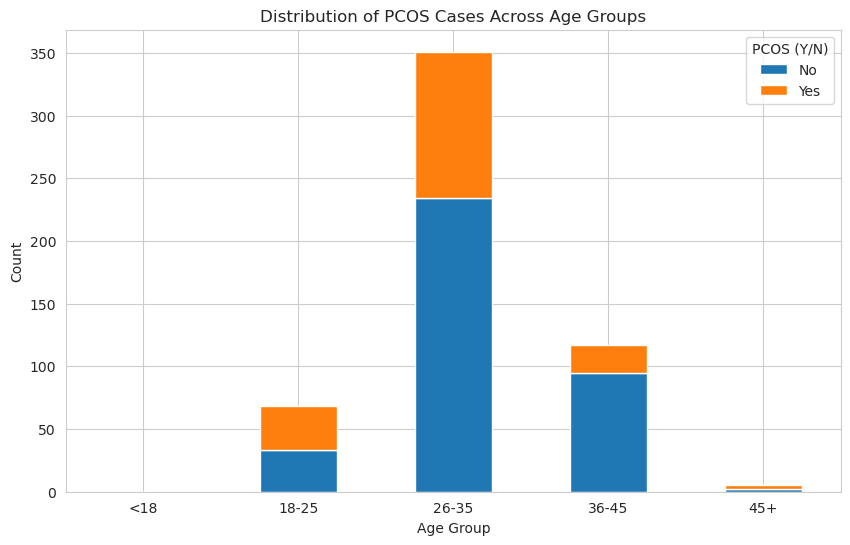

In [119]:
age_group_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Distribution of PCOS Cases Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='PCOS (Y/N)', loc='upper right', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.show()

It can be observed from above plot that PCOS affects mainly the age group of 26-35 and 18-15.

**2. Distribution analysis for numerical attributes**

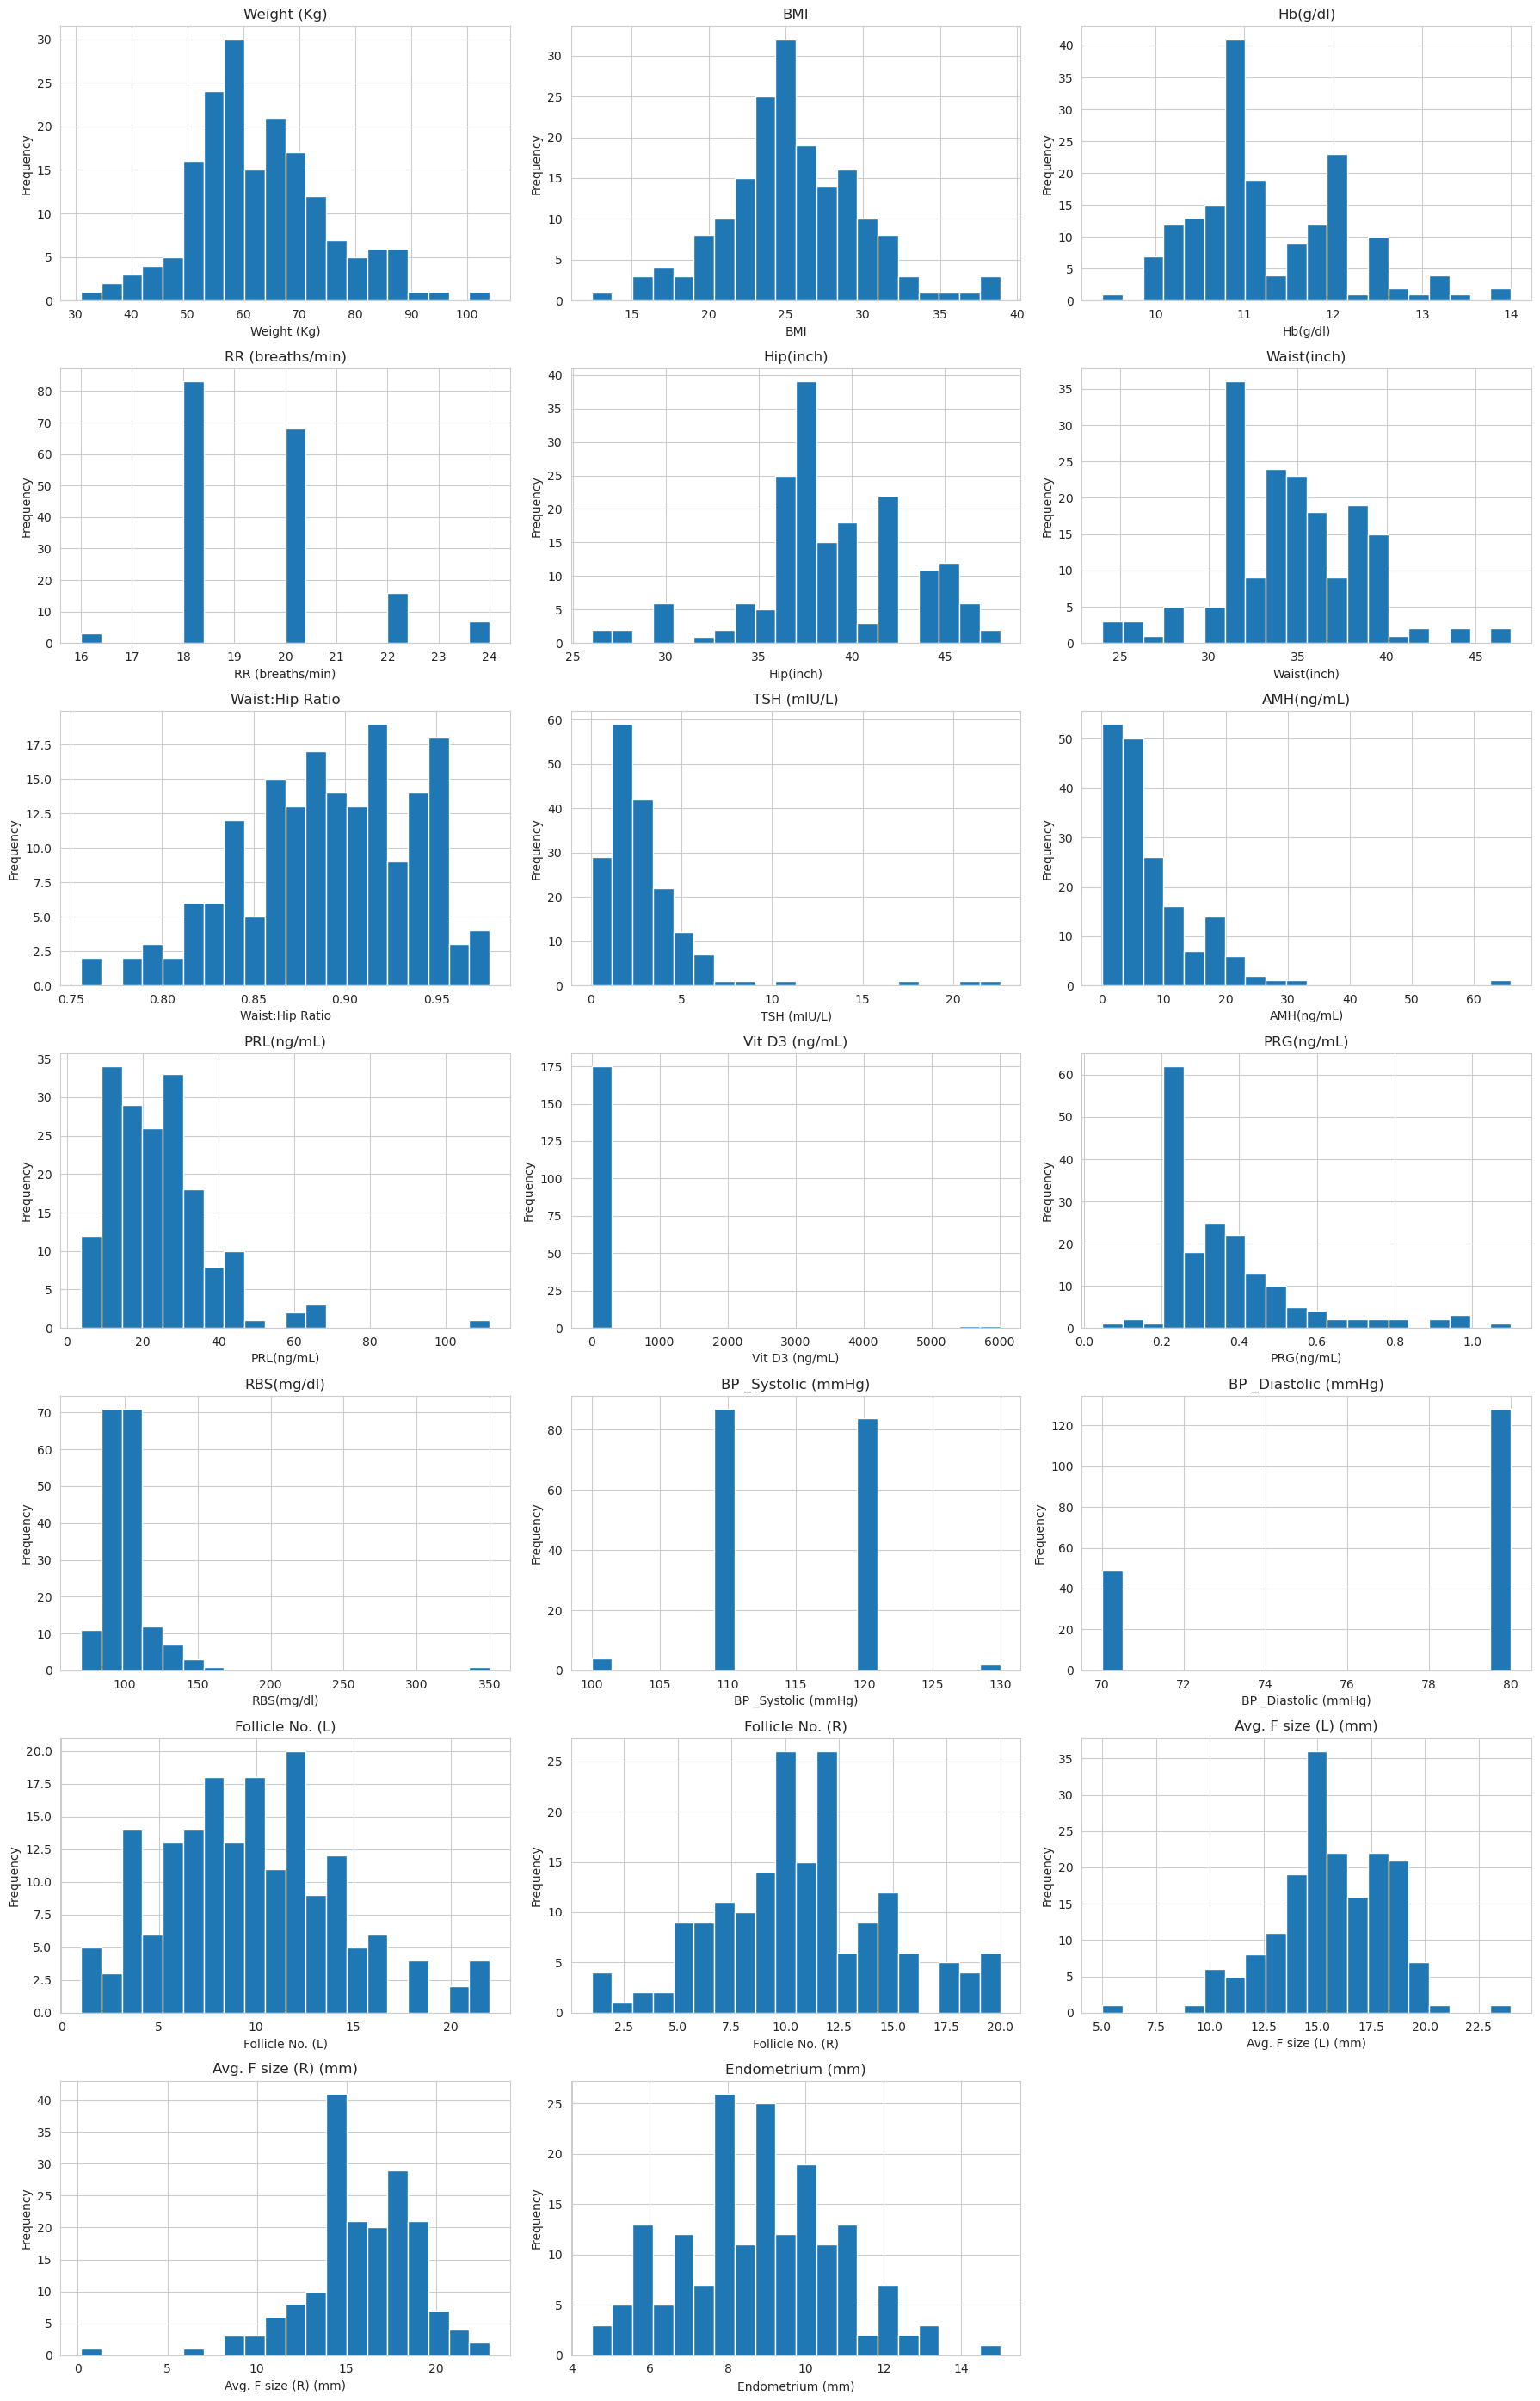

In [135]:
# List of numerical attributes for distribution analysis
numerical_attributes = ['Weight (Kg)', 'BMI', 'Hb(g/dl)','RR (breaths/min)',
                        'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)',
                        'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)',
                        'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)',
                        'Endometrium (mm)']

df_pcos = df[df['PCOS (Y/N)']==1]

# Determine grid size (3 per row)
num_cols = 3
num_rows = math.ceil(len(numerical_attributes) / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows*4))
axes = axes.flatten()  # flatten axes array

for i, attribute in enumerate(numerical_attributes):
    axes[i].hist(df_pcos[attribute], bins=20)
    axes[i].set_title(f'{attribute}')
    axes[i].set_xlabel(attribute)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True)

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [121]:
top_10_features = correlation_with_target[0:11]
print(top_10_features)

PCOS (Y/N)              1.000000
Follicle No. (R)        0.648327
Follicle No. (L)        0.603346
Skin darkening (Y/N)    0.475733
hair growth(Y/N)        0.464667
Weight gain(Y/N)        0.441047
Cycle(R/I)              0.401644
Fast food (Y/N)         0.377933
Pimples(Y/N)            0.286077
AMH(ng/mL)              0.263863
Weight (Kg)             0.211938
Name: PCOS (Y/N), dtype: float64


In [122]:
df_new.isnull().sum()

PCOS (Y/N)              0
Follicle No. (R)        0
Follicle No. (L)        0
Skin darkening (Y/N)    0
hair growth(Y/N)        0
Weight gain(Y/N)        0
Cycle(R/I)              0
Fast food (Y/N)         0
Pimples(Y/N)            0
AMH(ng/mL)              0
Weight (Kg)             0
dtype: int64

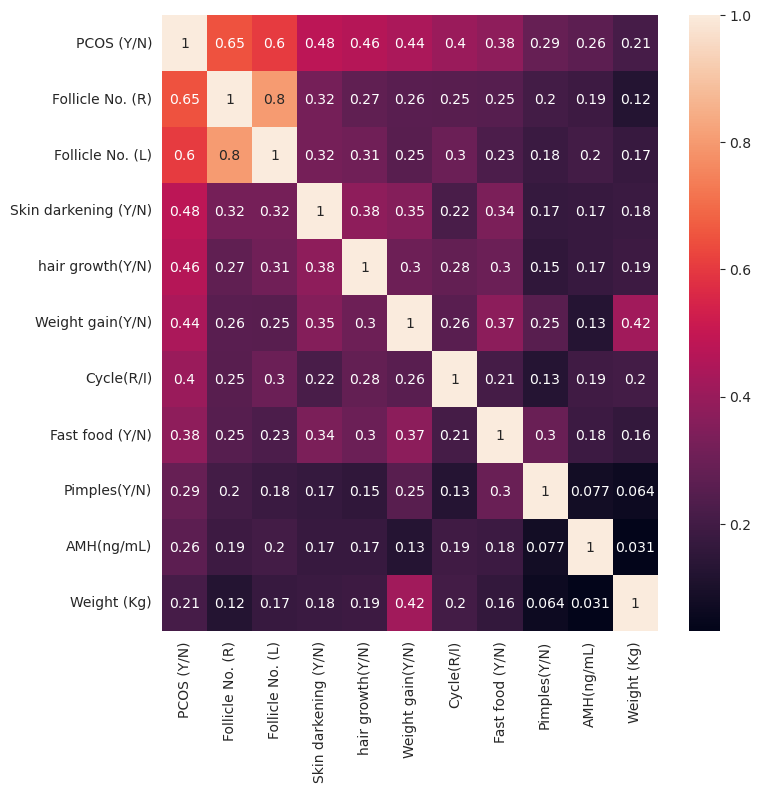

In [123]:
plt.figure(figsize=(8,8))
sns.heatmap(df_new.corr(),annot=True)
plt.show()

In [124]:
df_new['PCOS (Y/N)'].value_counts()

0    362
1    177
Name: PCOS (Y/N), dtype: int64

# Machine Learning Model 

In [125]:
def load_and_preprocess_data(filepath):
    """Load and preprocess the PCOS dataset"""
    print("Loading data...")
    
    # Check file extension and load accordingly
    if filepath.endswith('.xlsx') or filepath.endswith('.xls'):
        df = pd.read_excel(filepath, sheet_name='Full_new')
        print("Loaded Excel file (sheet: Full_new)")
    elif filepath.endswith('.csv'):
        df = pd.read_csv(filepath)
        print("Loaded CSV file")
    else:
        raise ValueError("File must be .xlsx, .xls, or .csv format")
    
    print(f"Initial dataset shape: {df.shape}")
    print(f"\nColumn names found:")
    print(df.columns.tolist())
    
    # Drop unnecessary columns
    cols_to_drop = ['Sl. No', 'Patient File No.', 'Unnamed: 44', 
                    'Sl.No', 'Patient File No', 'PCOS']
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')
    
    # Standardize column names - remove extra spaces
    df.columns = df.columns.str.strip()
    
    # Convert all object columns to numeric where possible
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Handle missing values
    # For numerical columns, fill with median
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    
    print(f"\nFinal dataset shape: {df.shape}")
    print(f"Missing values after preprocessing: {df.isnull().sum().sum()}")
    
    return df


# 2. FEATURE ENGINEERING

In [126]:
def create_engineered_features(df):
    """Create additional features based on domain knowledge - adaptive to available columns"""
    df_eng = df.copy()
    
    # Check which columns are available
    cols = df_eng.columns.tolist()
    
    # Hormonal ratios (if available)
    if 'LH(mIU/mL)' in cols and 'FSH(mIU/mL)' in cols:
        df_eng['LH_FSH_ratio'] = df_eng['LH(mIU/mL)'] / (df_eng['FSH(mIU/mL)'] + 1e-6)
    
    # Symptom aggregation (if available)
    symptom_cols = ['Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 
                    'Hair loss(Y/N)', 'Pimples(Y/N)']
    available_symptoms = [col for col in symptom_cols if col in cols]
    if available_symptoms:
        df_eng['symptom_count'] = df_eng[available_symptoms].sum(axis=1)
    
    # Follicle features (if available)
    if 'Follicle No. (L)' in cols and 'Follicle No. (R)' in cols:
        df_eng['total_follicles'] = df_eng['Follicle No. (L)'] + df_eng['Follicle No. (R)']
        df_eng['follicle_asymmetry'] = abs(df_eng['Follicle No. (L)'] - df_eng['Follicle No. (R)'])
    
    if 'Avg. F size (L) (mm)' in cols and 'Avg. F size (R) (mm)' in cols:
        df_eng['avg_follicle_size'] = (df_eng['Avg. F size (L) (mm)'] + df_eng['Avg. F size (R) (mm)']) / 2
    
    # Lifestyle score (if available)
    if 'Fast food (Y/N)' in cols and 'Reg.Exercise(Y/N)' in cols:
        df_eng['lifestyle_risk'] = df_eng['Fast food (Y/N)'] - df_eng['Reg.Exercise(Y/N)']
    
    # BMI categories (if available)
    if 'BMI' in cols:
        df_eng['BMI_category'] = pd.cut(df_eng['BMI'], 
                                         bins=[0, 18.5, 25, 30, 100], 
                                         labels=[0, 1, 2, 3]).astype(int)
    
    # Waist-Hip ratio category (if available)
    if 'Waist:Hip Ratio' in cols:
        df_eng['WHR_risk'] = (df_eng['Waist:Hip Ratio'] > 0.85).astype(int)
    
    # Age categories (if available)
    if 'Age (yrs)' in cols:
        df_eng['age_group'] = pd.cut(df_eng['Age (yrs)'], 
                                      bins=[0, 20, 25, 30, 35, 100], 
                                      labels=[0, 1, 2, 3, 4]).astype(int)
    
    print(f"\nEngineered features created. New shape: {df_eng.shape}")
    
    return df_eng

# 3. MODEL TRAINING WITH ENSEMBLE

In [127]:
def train_ensemble_model(X_train, y_train):
    """Train an ensemble of models for better performance"""
    
    # Individual models with optimized parameters
    lr = LogisticRegression(max_iter=2000, C=0.1, class_weight='balanced', random_state=42)
    
    rf = RandomForestClassifier(n_estimators=300, max_depth=6, 
                                 min_samples_split=6, min_samples_leaf=3,
                                 class_weight='balanced', oob_score=True, random_state=42)
    
    gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, 
                                     max_depth=3, subsample=0.8, random_state=42)
    ada = AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
    
    # Create voting classifier (soft voting for probability averaging)
    ensemble = StackingClassifier(
        estimators=[('rf', rf), ('gb', gb)],
        final_estimator=LogisticRegression(max_iter=2000)
    )
    
    print("Training ensemble model...")
    ensemble.fit(X_train, y_train)
    
    # Also train individual models for comparison
    models = {
        'Random Forest': rf,
        'Gradient Boosting': gb,
        'Ensemble': ensemble
    }
    
    return models

# 4. MODEL EVALUATION

In [128]:
def evaluate_models(models, X_test, y_test):
    """Evaluate all models and return performance metrics"""
    results = {}
    
    for name, model in models.items():
        if name != 'Ensemble':
            model.fit(X_test.iloc[:int(len(X_test)*0.8)], 
                     y_test.iloc[:int(len(y_test)*0.8)])
        
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        results[name] = {
            'accuracy': accuracy_score(y_test, y_pred),
            'confusion_matrix': confusion_matrix(y_test, y_pred),
            'classification_report': classification_report(y_test, y_pred, output_dict=True),
            'roc_auc': roc_auc_score(y_test, y_prob)
        }
        
        print(f"\n{'='*50}")
        print(f"Model: {name}")
        print(f"{'='*50}")
        print(f"Accuracy: {results[name]['accuracy']:.4f}")
        print(f"ROC-AUC Score: {results[name]['roc_auc']:.4f}")
        print(f"\nConfusion Matrix:\n{results[name]['confusion_matrix']}")
        print(f"\nClassification Report:")
        print(classification_report(y_test, y_pred))
    
    return results
    
# 4B. PERFORMANCE COMPARISON PLOT (Train vs Test)

def plot_overfitting(models, X_train, y_train, X_test, y_test):
    """Plot train vs test accuracy for all models to visualize overfitting"""
    
    performance = {'Model': [], 'Train Accuracy': [], 'Test Accuracy': []}

    for name, model in models.items():
        print(f"Evaluating overfitting for: {name}")

        # Train on training data only
        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Accuracy scores
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        performance['Model'].append(name)
        performance['Train Accuracy'].append(train_acc)
        performance['Test Accuracy'].append(test_acc)

    # Convert to DataFrame for plotting
    perf_df = pd.DataFrame(performance)
    print("\nTrain vs Test Accuracy:\n", perf_df)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(perf_df['Model'], perf_df['Train Accuracy'], marker='o', label='Train Accuracy')
    plt.plot(perf_df['Model'], perf_df['Test Accuracy'], marker='o', label='Test Accuracy')
    plt.title("Model Performance Comparison (Train vs Test)")
    plt.xlabel("Model")
    plt.ylabel("Accuracy")
    plt.ylim(0,1)
    plt.grid(True)
    plt.legend()
    plt.show()

# 5. PREDICTION FUNCTION

In [129]:
def predict_pcos(model, scaler, feature_names, patient_data):
    """
    Predict PCOS for a new patient
    
    Parameters:
    -----------
    model : trained model
    scaler : fitted StandardScaler
    feature_names : list of feature names used in training
    patient_data : dict with patient features
    
    Returns:
    --------
    prediction : 'Yes' or 'No'
    probability : probability of having PCOS
    """
    # Convert patient data to DataFrame
    patient_df = pd.DataFrame([patient_data])
    
    # Ensure all required features are present
    for feature in feature_names:
        if feature not in patient_df.columns:
            patient_df[feature] = 0
    
    # Select only the features used in training
    patient_df = patient_df[feature_names]
    
    # Scale the features
    patient_scaled = scaler.transform(patient_df)
    
    # Make prediction
    prediction = model.predict(patient_scaled)[0]
    probability = model.predict_proba(patient_scaled)[0][1]
    
    result = "Yes" if prediction == 1 else "No"
    
    return result, probability

# 6. MAIN EXECUTION PIPELINE

In [130]:
def main(filepath):
    """Main execution pipeline"""
    
    # Load and preprocess data
    df = load_and_preprocess_data(filepath)
    
    # Check if target column exists
    target_col = None
    possible_targets = ['PCOS (Y/N)', 'PCOS(Y/N)', 'PCOS', 'PCOS (Y/N)']
    for col in possible_targets:
        if col in df.columns:
            target_col = col
            break
    
    if target_col is None:
        raise ValueError(f"Target column not found! Available columns: {df.columns.tolist()}")
    
    print(f"\nUsing target column: '{target_col}'")
    
    # Feature engineering
    df_eng = create_engineered_features(df)
    
    # Separate features and target
    X = df_eng.drop(target_col, axis=1)
    y = df_eng[target_col]
    
    print(f"\nFeatures shape: {X.shape}")
    print(f"Available features: {X.columns.tolist()}")
    
    print(f"\nClass distribution:")
    print(y.value_counts())
    if len(y.value_counts()) > 1:
        print(f"Class balance: {y.value_counts()[1]/len(y)*100:.2f}% positive cases")
    
    # Check if we have enough features
    if X.shape[1] < 3:
        print("\n WARNING: Very few features available. Model performance may be limited.")
        print("Consider using the full dataset with all 44+ features for better results.")
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Handle class imbalance with SMOTE (only if we have multiple classes)
    if len(y.value_counts()) > 1:
        print("\nApplying SMOTE for class balancing...")
        smote_tomek = SMOTETomek(random_state=42)
        X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train, y_train)
        
        print(f"Training set size after SMOTE: {X_train_balanced.shape}")
        print(f"Class distribution after SMOTE: {pd.Series(y_train_balanced).value_counts()}")
    else:
        X_train_balanced, y_train_balanced = X_train, y_train
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_balanced)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert back to DataFrame for compatibility
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)
    y_train_balanced = pd.Series(y_train_balanced)
    
    # Train models
    models = train_ensemble_model(X_train_scaled, y_train_balanced)
    
    # Evaluate models
    results = evaluate_models(models, X_test_scaled, y_test)
    # Plot Train vs Test accuracy for overfitting check
    plot_overfitting(models, X_train_scaled, y_train_balanced, X_test_scaled, y_test)

    
    # Select best model (Ensemble)
    best_model = models['Ensemble']
    
    # Feature importance (from Random Forest)
    if X.shape[1] >= 2:  # Only show importance if we have features
        rf_model = models['Random Forest']
        rf_model.fit(X_train_scaled, y_train_balanced)
        feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': rf_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("\n" + "="*50)
        print("Top 15 Most Important Features:")
        print("="*50)
        print(feature_importance.head(15))
    
    return best_model, scaler, X.columns.tolist(), results

#  7. EXAMPLE USAGE

Loading data...
Loaded Excel file (sheet: Full_new)
Initial dataset shape: (541, 45)

Column names found:
['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)', 'Unnamed: 44']

Final dataset shape: (541, 42)
Missing values after preprocessing: 0

Using target column: 'PCOS

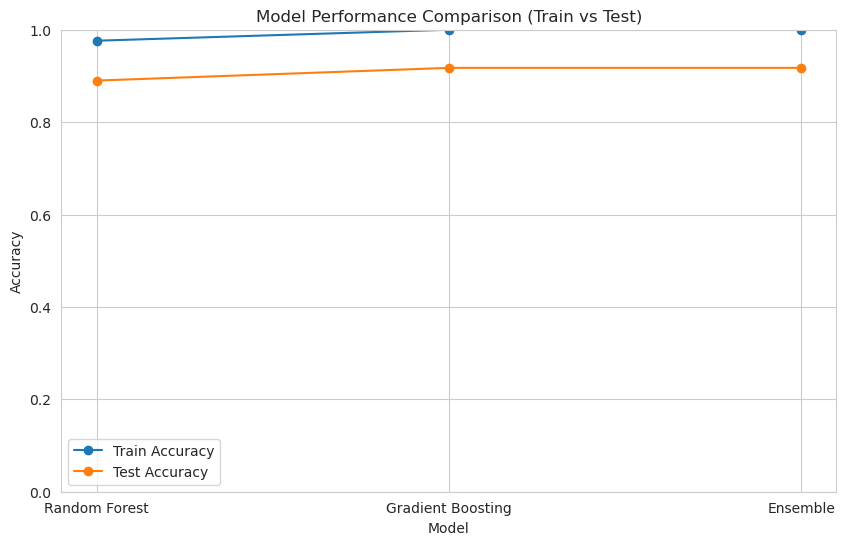


Top 15 Most Important Features:
                 feature  importance
43       total_follicles    0.194694
37      Follicle No. (R)    0.135863
36      Follicle No. (L)    0.095941
42         symptom_count    0.093523
32       Fast food (Y/N)    0.043540
9     Cycle length(days)    0.042464
46        lifestyle_risk    0.026492
22            AMH(ng/mL)    0.026332
27      Weight gain(Y/N)    0.021143
29  Skin darkening (Y/N)    0.020755
3                    BMI    0.017793
8             Cycle(R/I)    0.016699
44    follicle_asymmetry    0.016072
1            Weight (Kg)    0.014186
26            RBS(mg/dl)    0.013746

EXAMPLE PREDICTION FOR NEW PATIENT

PCOS Prediction: No
Confidence: 18.26%

✓ The patient shows low indicators of PCOS.
Recommendation: Continue regular health monitoring.


In [131]:
if __name__ == "__main__":
    # Train the model
    filepath = "/kaggle/input/polycystic-ovary-syndrome-pcos/PCOS_data_without_infertility.xlsx"
    model, scaler, feature_names, results = main(filepath)
    
    # Example: Predict for a new patient
    print("\n" + "="*50)
    print("EXAMPLE PREDICTION FOR NEW PATIENT")
    print("="*50)
    
    new_patient = {
        'Age (yrs)': 18,
        'Weight (Kg)': 70,
        'Height(Cm)': 160,
        'BMI': 27.34,
        'Blood Group': 11,
        'Pulse rate(bpm)': 76,
        'RR (breaths/min)': 18,
        'Hb(g/dl)': 12.5,
        'Cycle(R/I)': 4,
        'Cycle length(days)': 35,
        'Marraige Status (Yrs)': 2.0,
        'Pregnant(Y/N)': 0,
        'No. of aborptions': 0,
        'I   beta-HCG(mIU/mL)': 0.5,
        'II    beta-HCG(mIU/mL)': 0.5,
        'FSH(mIU/mL)': 5.5,
        'LH(mIU/mL)': 12.0,
        'FSH/LH': 0.46,
        'Hip(inch)': 38,
        'Waist(inch)': 32,
        'Waist:Hip Ratio': 0.84,
        'TSH (mIU/L)': 2.5,
        'AMH(ng/mL)': 8.5,
        'PRL(ng/mL)': 15.0,
        'Vit D3 (ng/mL)': 20.0,
        'PRG(ng/mL)': 0.8,
        'RBS(mg/dl)': 95.0,
        'Weight gain(Y/N)': 1,
        'hair growth(Y/N)': 1,
        'Skin darkening (Y/N)': 1,
        'Hair loss(Y/N)': 0,
        'Pimples(Y/N)': 1,
        'Fast food (Y/N)': 1.0,
        'Reg.Exercise(Y/N)': 0,
        'BP _Systolic (mmHg)': 120,
        'BP _Diastolic (mmHg)': 80,
        'Follicle No. (L)': 12,
        'Follicle No. (R)': 14,
        'Avg. F size (L) (mm)': 18.0,
        'Avg. F size (R) (mm)': 19.0,
        'Endometrium (mm)': 9.0
    }
    
    prediction, probability = predict_pcos(model, scaler, feature_names, new_patient)
    
    print(f"\nPCOS Prediction: {prediction}")
    print(f"Confidence: {probability*100:.2f}%")
    
    if prediction == "Yes":
        print("\n⚠️ The patient shows indicators of PCOS.")
        print("Recommendation: Consult with a healthcare professional for proper diagnosis.")
    else:
        print("\n✓ The patient shows low indicators of PCOS.")
        print("Recommendation: Continue regular health monitoring.")